# 05 — Model Evaluation + Explainability (SHAP)
**PIX Fraud Intelligence | IBM Portfolio Project**

**Goals:**
- Score the held-out test set via the WML endpoint
- Compute classification metrics (ROC-AUC, F1, Precision-Recall)
- Generate SHAP explanations — *why* a transaction was flagged as fraud
- Frame results in terms of LGPD compliance

**LGPD context:**  
> Art. 20 — O titular dos dados tem direito a solicitar revisão de decisões tomadas unicamente com base em tratamento automatizado.  
> SHAP values provide the per-feature contribution that enables this explanation.

In [1]:
import sys
sys.path.append('..')

import json
import tarfile
import tempfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from src.wml_scorer import WMLScorer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Load Test Set from DB2

In [2]:
from src.db2_connector import DB2Connector

with DB2Connector('../config/credentials.json') as conn:
    test_df = conn.query("SELECT * FROM TRANSACTIONS WHERE SPLIT = 'test'")

test_df.columns = test_df.columns.str.lower()
y_test = test_df['fraude'].values
X_test = test_df.drop(columns=['fraude', 'split'])

print(f'Test set from DB2: {X_test.shape}')
print(f'Fraud rate: {y_test.mean():.4%}')

Test set from DB2: (20000, 11)
Fraud rate: 13.7350%


## 2. Score via WML Endpoint
Add `scoring_url` to your `config/credentials.json` from notebook 04.

In [3]:
with open('../config/credentials.json') as f:
    config = json.load(f)

with open('../config/deployment_meta.json') as f:
    meta = json.load(f)

# Pass the scoring URL from deployment_meta.json explicitly — no need to edit credentials.json
scorer = WMLScorer('../config/credentials.json', scoring_url=meta['scoring_url'])

all_predictions = []
batch_size = 500
for i in range(0, len(X_test), batch_size):
    batch = X_test.iloc[i:i + batch_size]
    preds = scorer.score_dataframe(batch)
    all_predictions.extend(preds)
    if i % 5000 == 0:
        print(f'  Scored {min(i + batch_size, len(X_test)):,} / {len(X_test):,}')

y_pred = np.array([p['prediction'] for p in all_predictions])
y_prob = np.array([p['probability'][1] for p in all_predictions])
print(f'\nScoring complete. Predictions shape: {y_pred.shape}')

  Scored 500 / 20,000


  Scored 5,500 / 20,000


  Scored 10,500 / 20,000


  Scored 15,500 / 20,000



Scoring complete. Predictions shape: (20000,)


## 3. Classification Metrics

In [4]:
auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {auc:.4f}\n')
print(classification_report(y_test, y_pred, target_names=['Legítima', 'Fraude']))

ROC-AUC: 0.9962

              precision    recall  f1-score   support

    Legítima       0.99      0.99      0.99     17253
      Fraude       0.93      0.95      0.94      2747

    accuracy                           0.98     20000
   macro avg       0.96      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



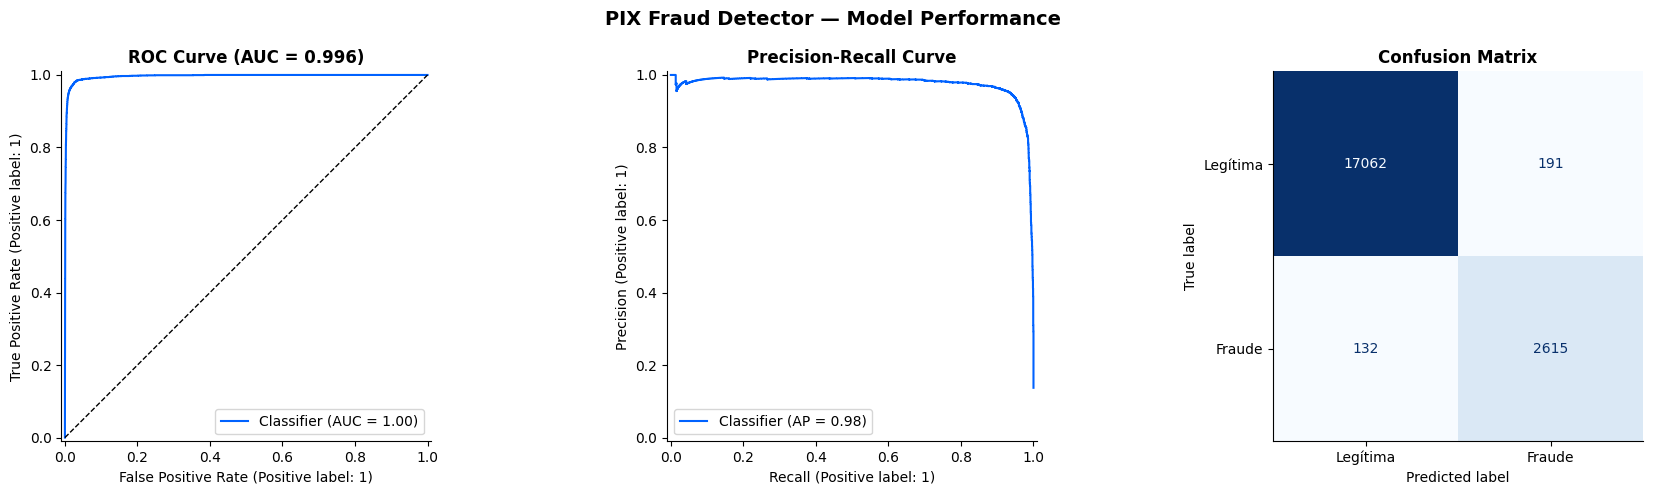

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], color='#0062ff')
axes[0].set_title(f'ROC Curve (AUC = {auc:.3f})', fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='#0062ff')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[2],
    display_labels=['Legítima', 'Fraude'],
    colorbar=False, cmap='Blues'
)
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.suptitle('PIX Fraud Detector — Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SHAP Explainability
SHAP (SHapley Additive exPlanations) attributes model predictions to individual features,  
enabling human-readable explanations required by LGPD Art. 20.

In [6]:
from ibm_watsonx_ai.experiment import AutoAI
from ibm_watsonx_ai import Credentials

# The deployed AutoAI model archive isn't directly unpicklable locally; instead we
# export the trained pipeline straight from the AutoAI run as a scikit-learn Pipeline.
wml_credentials = Credentials(api_key=config['wml']['apikey'], url=config['wml']['url'])
experiment = AutoAI(wml_credentials, space_id=config['wml']['space_id'])

runs_df = experiment.runs.list()
run_id = runs_df[runs_df['state'] == 'completed'].iloc[0]['run_id']
optimizer = experiment.runs.get_optimizer(run_id=run_id)

pipeline = optimizer.get_pipeline(meta['best_pipeline'], astype='sklearn')

print(f'Pipeline loaded: {type(pipeline).__name__}')
print(f'Steps: {[s[0] for s in pipeline.steps]}')

Pipeline loaded: Pipeline
Steps: ['featureunion', 'numpypermutearray', 'ta2', 'fs1-1', 'ta1', 'fs1-2', 'lgbmclassifier']


In [7]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=500, replace=False)
X_shap = X_test.iloc[sample_idx]

final_estimator = pipeline.steps[-1][1]
explainer = shap.TreeExplainer(final_estimator)

from sklearn.pipeline import Pipeline as SKPipeline
preprocessor = SKPipeline(pipeline.steps[:-1])
# AutoAI preprocessing steps expect a numpy array
X_transformed = preprocessor.transform(X_shap.values)

shap_values = explainer.shap_values(X_transformed)
print(f'SHAP values computed for {len(X_shap)} samples. Shape: {np.asarray(shap_values).shape}')

SHAP values computed for 500 samples. Shape: (500, 11)


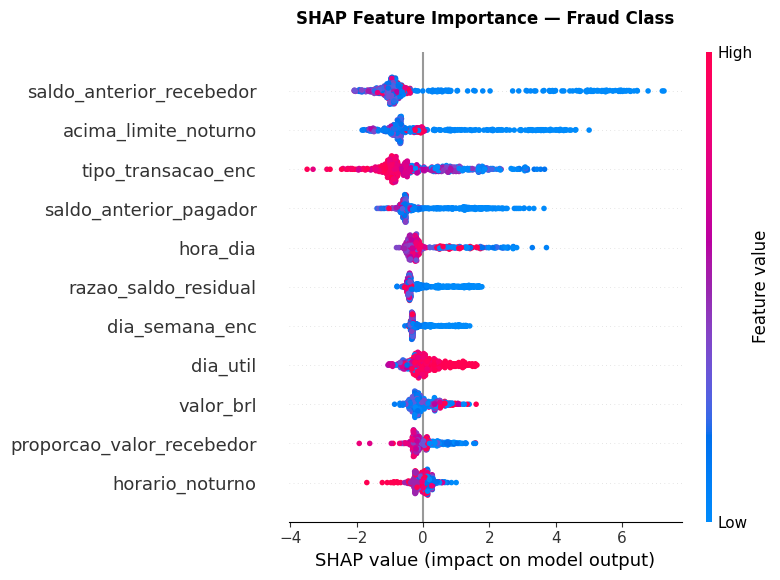

In [8]:
# Summary plot — global feature importance
shap_fraud = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_fraud, X_transformed,
    feature_names=X_test.columns.tolist(),
    show=False, max_display=15
)
plt.title('SHAP Feature Importance — Fraud Class', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../assets/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining transaction #16928 (predicted: FRAUD)


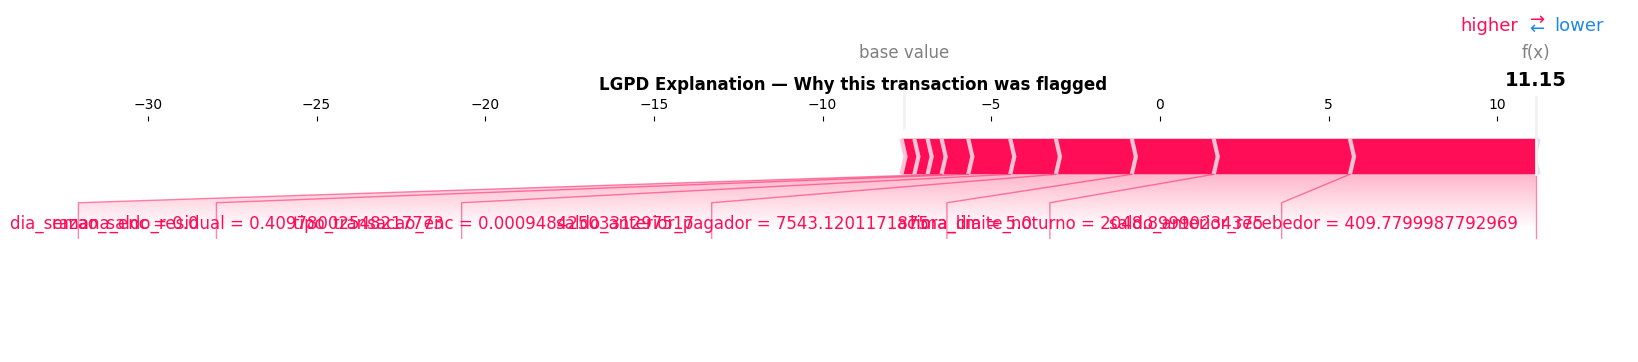

In [9]:
# Individual explanation — explain a single flagged transaction
fraud_indices = np.where(y_pred[sample_idx] == 1)[0]
if len(fraud_indices) > 0:
    idx = fraud_indices[0]
    print(f'Explaining transaction #{sample_idx[idx]} (predicted: FRAUD)')
    shap.force_plot(
        explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        shap_fraud[idx],
        X_transformed[idx],
        feature_names=X_test.columns.tolist(),
        matplotlib=True,
        show=False
    )
    plt.title('LGPD Explanation — Why this transaction was flagged', fontweight='bold')
    plt.savefig('../assets/shap_force_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No fraud predictions in sample — try a larger sample size.')

## 5. Results Summary
Print a clean summary for the README.

In [10]:
results = {
    'ROC-AUC':    round(roc_auc_score(y_test, y_prob), 4),
    'F1 (fraud)': round(f1_score(y_test, y_pred), 4),
    'Precision':  round(precision_score(y_test, y_pred), 4),
    'Recall':     round(recall_score(y_test, y_pred), 4),
}

print('=' * 40)
print('  PIX Fraud Detector — Final Results')
print('=' * 40)
for k, v in results.items():
    print(f'  {k:<20} {v}')
print('=' * 40)

with open('../config/results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved to config/results.json')

  PIX Fraud Detector — Final Results
  ROC-AUC              0.9962
  F1 (fraud)           0.9418
  Precision            0.9319
  Recall               0.9519
Results saved to config/results.json
